# PyDoseRT dose calculation from a DICOM dataset

**Author:** Attila Simkó

This example shows how we can load a DICOM-based treatment case and recompute dose with PyDoseRT in four steps:

1. Download and extract a reference DICOM dataset,
2. Load the CT, structures, beam sequence, and reference dose,
3. Initialize the PyDoseRT dose engine and recompute dose,
4. Compare the predicted dose with the reference dose distribution.

This provides a compact example of how PyDoseRT can be used with standard radiotherapy data.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import urllib.request
import zipfile

import pydosert as PDRT
from pydosert.utils.plotting import compute_fluence_maps, plot_fluence_and_mu, plot_mu_polar, plot_overview
from pydosert.data.loaders import load_dicom

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

pydosert is already installed


## Load a reference dataset

We use a small DICOM example that includes:

- a CT image of a phantom,
- structure contours,
- a treatment plan,
- and a reference dose distribution.

This lets us compare a PyDoseRT dose calculation against a simple, yet clinically exported reference.

In [2]:
zip_url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/mr_alderson.zip"

zip_path = Path("data/mr_alderson.zip")
extract_dir = Path("data/mr_alderson")

folder_ready = extract_dir.exists() and any(extract_dir.iterdir())

if not folder_ready:
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print("Downloading zip...")
        urllib.request.urlretrieve(zip_url, zip_path)

    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    print(f"Done. Extracted to {extract_dir}")
else:
    print(f"{extract_dir} already exists and is not empty, skipping.")

data/mr_alderson already exists and is not empty, skipping.


## Load the patient, beam sequence, and reference dose

Next, we read the DICOM folders and files into PyDoseRT objects.

This step gives us:

- a `Patient` object with CT, structures, and reference dose,
- a beam sequence from the RT plan,
- and a consistent geometry for dose recalculation.

PyDoseRT is **not a DICOM loader**. We aimed to develop a general loader that we tested on our datasets, however it is very likely to break when tested extensively. We recommend building a `BeamSequence` from the plans manually, with the leaf positions, jaw positions and monitor unit values extracted directly from the plans.

In [3]:
# Set paths
ct_folder = "data/mr_alderson/CT/"
rtplan_path = "data/mr_alderson/RP/RP1.2.752.243.1.1.20251104150801227.3200.53550.dcm"
rtdose_path = ["data/mr_alderson/RD/RD1.2.752.243.1.1.20251104150801227.3300.46671.dcm", "data/mr_alderson/RD/RD1.2.752.243.1.1.20251104150801228.3500.71811.dcm"]
rtstruct_path = "data/mr_alderson/RS/RS1.2.752.243.1.1.20251104145623863.1100.46584.dcm"

roi_colors = {
    "PTV": "orange",
    "Bladder": "red",
    "Rectum": "green",
    "FemoralHead_L": "blue",
    "FemoralHead_R": "purple",
    "Body": "black",
}

patient, beam_sequence = load_dicom(
    ct_folder, 
    dose_path=rtdose_path, 
    plan_path=[rtplan_path], 
    struct_path=rtstruct_path, 
    struct_names=["PTV", "Bladder", "Rectum", "FemoralHead_L", "FemoralHead_R", "Body"])
beam_sequence = beam_sequence[0]

## Inspect the loaded beam sequence

Before recomputing dose, it is useful to inspect the imported delivery data.

Here we visualize:

- left MLC positions,
- right MLC positions,
- monitor units across beams.

This provides a quick check that the treatment plan was loaded correctly.

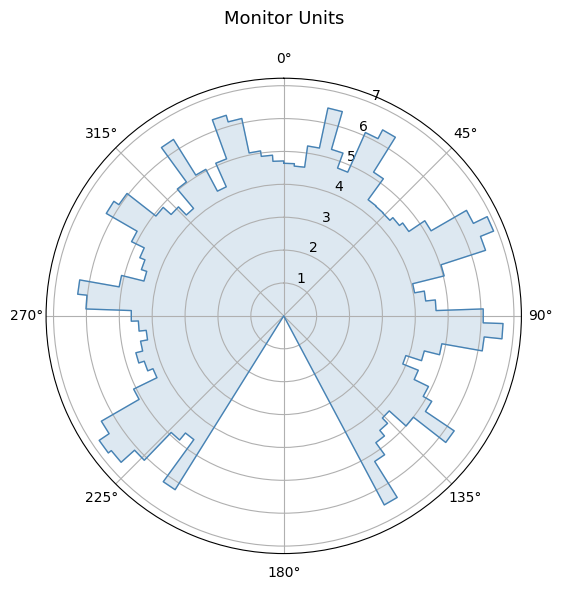

In [4]:
# Monitor units per control point as a polar plot (replaces the raw MLC heatmaps).
plot_mu_polar(beam_sequence)

## Initialize the dose engine and recompute dose

We now create a PyDoseRT dose engine using the imported beam sequence and patient geometry.

Internally, PyDoseRT uses a differentiable pencil-beam based dose model, so this same setup can also be used later for optimization workflows.

In this example we pass `beam_chunk_size=1`, which computes dose in gradient-checkpointed chunks (here one beam at a time) instead of a single call that computes all beams at once. This saves a significant amount of memory while preserving gradients, at the cost of slightly more time. Increase `beam_chunk_size` (or leave it unset) to trade memory for speed.

In [6]:
preset_path = Path(pydosert.data.__file__).parent / "machine_presets" / "varian_10MV.json"
config = PDRT.MachineConfig(
    preset=str(preset_path),
    number_of_leaf_pairs=80,
    leaf_widths=None,
)

dose_engine = PDRT.DoseEngine(
    config,
    25,
    patient.resolution,
    patient.density_image.shape,
    dtype=torch.float32,
    auto_calibrate=True,
    device=device,
)

dose_pred = dose_engine.compute_dose(
    beam_sequence.to(device).to(dtype),
    density_image=patient.density_image.to(device).to(dtype),
    beam_chunk_size=1,
).cpu().detach().numpy()

## Compare the predicted dose with the reference dose

Finally, we compare the PyDoseRT dose against the reference dose in sagittal, coronal, and axial views.

We also compute a simple masked error inside the body contour to get a quick quantitative summary.

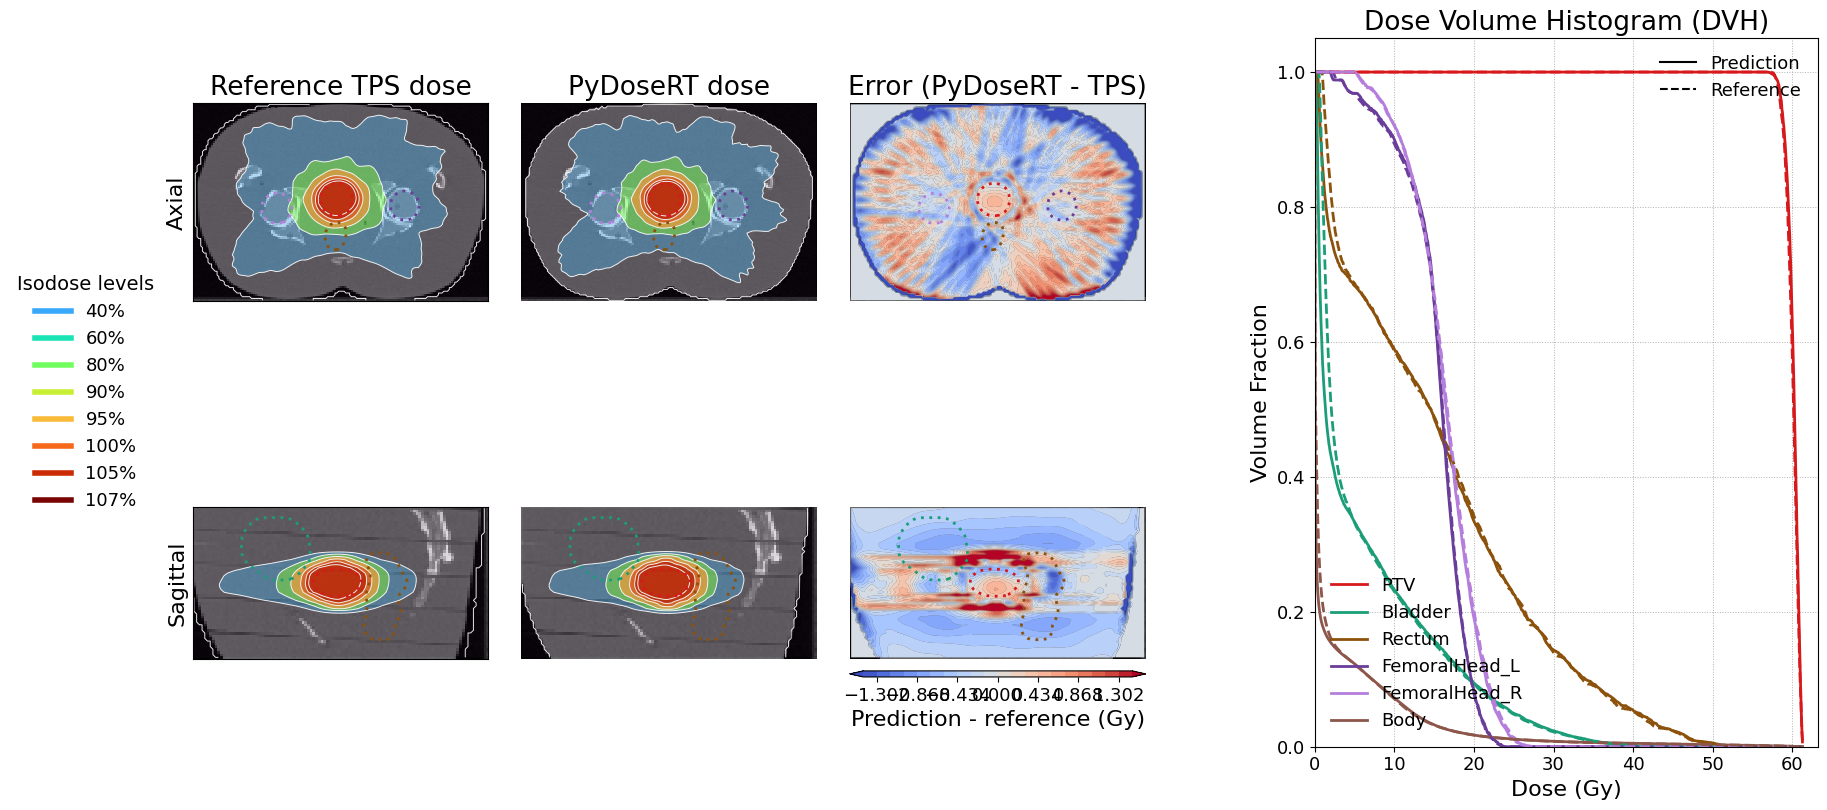

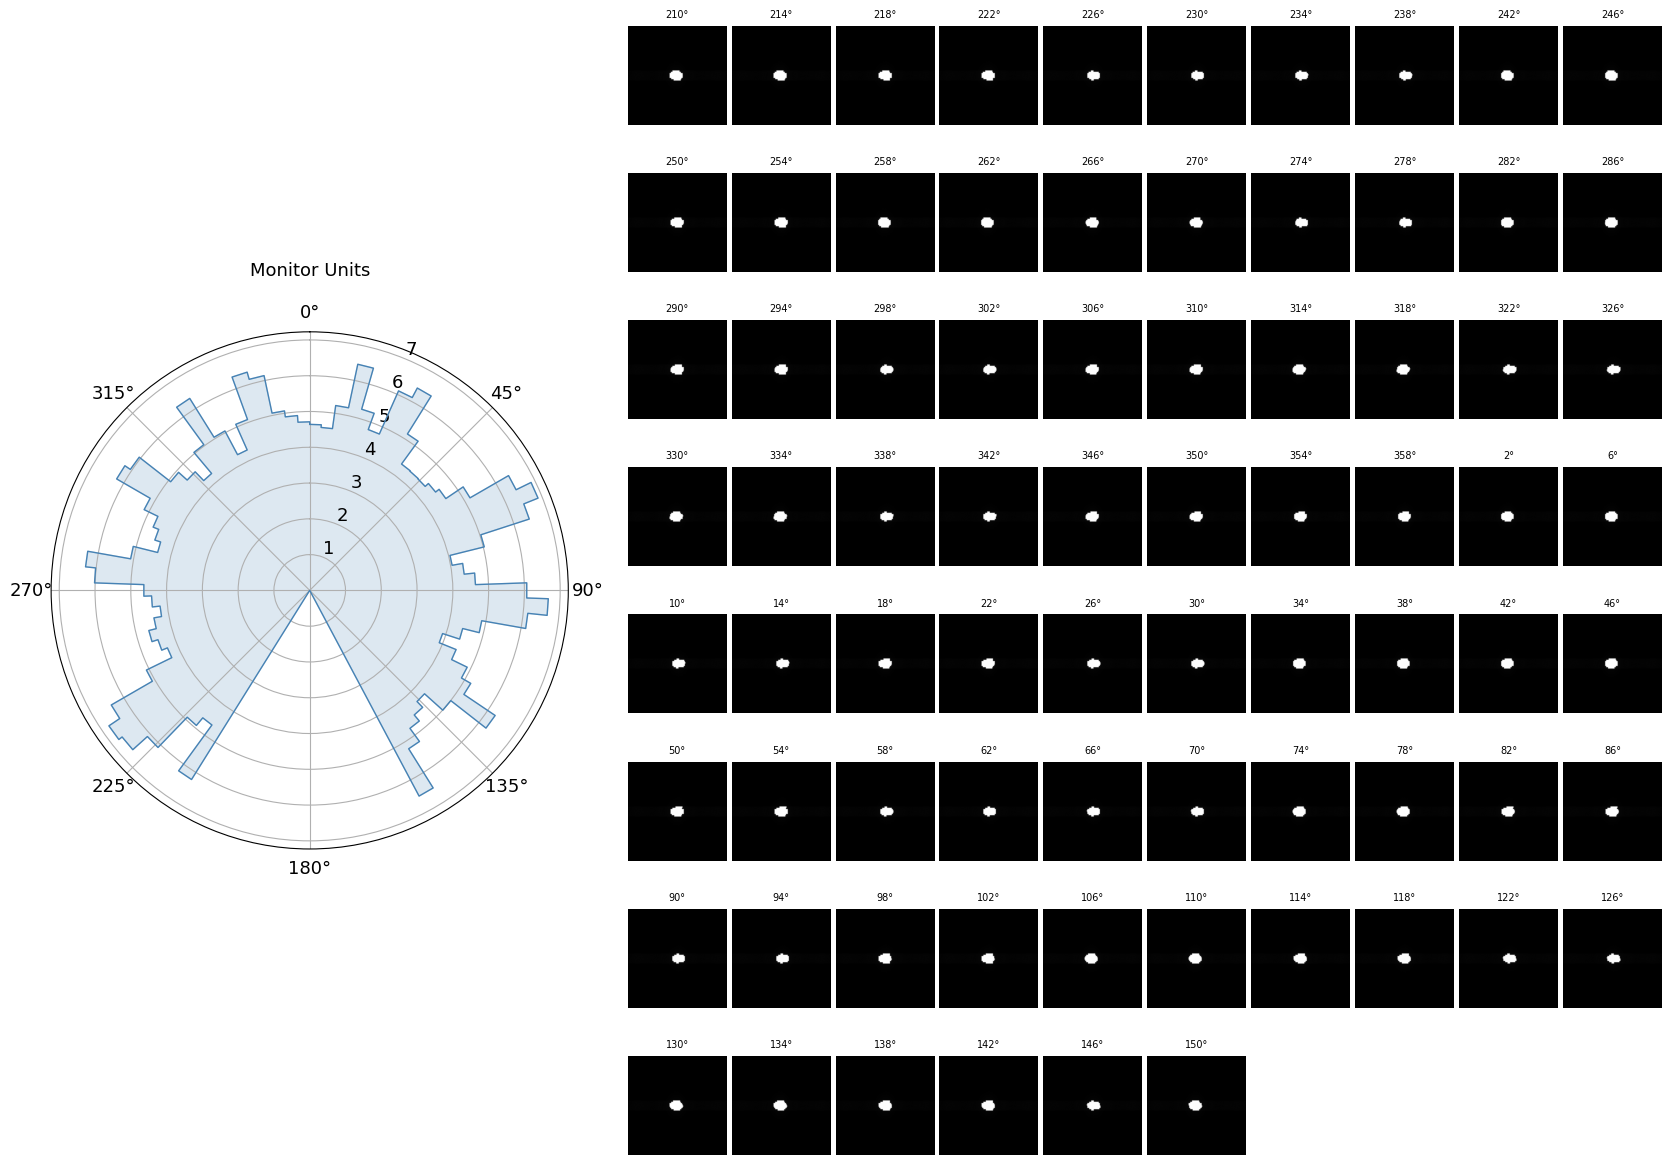

: 

In [ ]:
import torch

ext_mask = patient.structures["Body"].cpu().detach().numpy() > 0
dose_pred = ext_mask * dose_pred
dose_pred = dose_pred * (
    np.quantile(patient.dose.cpu().detach().numpy(), 0.999) / np.quantile(dose_pred, 0.999)
)

# Reference vs prediction overview (error map + DVH).
plot_overview(patient, dose_pred=torch.from_numpy(dose_pred[0]))

# Aperture fluence montage + polar MU (replaces the raw MLC/jaw position heatmaps).
bs = beam_sequence.to(device).to(dtype)
fluence_maps = compute_fluence_maps(dose_engine, bs)
plot_fluence_and_mu(bs, fluence_maps)

## Summary

In this example, we loaded a DICOM treatment case, recomputed dose with PyDoseRT, and compared the result with the reference dose exported from the original treatment workflow.